# Experimental Design
_It is the process by which we carry out research in an objective & controlled fashion._
## Definitions
**Subjects**: (what we're experimenting on- could be people/ users/ students etc.) can be divided into 2 test groups:
- **Treatment group:** group to which one changes are given; the group to be studied

- **Control group:** not given any change (the placebo group) ; results already known for this group


In [1]:
import  pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
hw_main = pd.read_csv('./datasets/weightsheights.csv')
hw_main.head()

,Height(Inches),Weight(Pounds),Height in cm,Weight in kg,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,category
0,65.78331,112.9925,167.089517,51.252597,2.0,160,0.393701,170.0,160-170
1,71.51521,136.4873,181.648535,61.909672,NaN,180,NaN,190.0,180-190
2,69.39874,153.0269,176.272704,69.411917,NaN,180,NaN,190.0,180-190
3,68.21660,142.3354,173.270070,64.562328,NaN,170,NaN,180.0,170-180
4,67.78781,144.2971,172.180944,65.452141,NaN,170,NaN,180.0,170-180


In [3]:
# extracting only the heights column
heights = hw_main[['Height in cm']]
heights.head()

,Height in cm
0,167.089517
1,181.648535
2,176.272704
3,173.270070
4,172.180944


## Assigning subjects to groups

**Non-random assignment**
- Split the dataframe manually using `.iloc`<br>
    Example: splitting a dataframe with 1K rows into `iloc[0:050]` & `iloc[501:1000]`


In [4]:
nonrandom_g1 = heights.iloc[0:(len(heights)//2)]
nonrandom_g2 = heights.iloc[(len(heights)//2):]
compare_nr = pd.concat([nonrandom_g1['Height in cm'].describe(), nonrandom_g2['Height in cm'].describe()], axis=1)
print(compare_nr)

       Height in cm  Height in cm
count  12500.000000  12500.000000
mean     172.668017    172.736814
std        4.838883      4.821573
min      153.956048    153.106952
25%      169.357926    169.507805
50%      172.676676    172.754502
75%      175.915257    176.002468
max      190.888009    190.116103


>**Random assignment**
- Using `.sample()` method with no replacement

Definition :
>Randomization is **the process of assigning subjects to treatment groups using a random mechanism**, so that treatment assignment is independent of subjects' pre-existing characteristics.

Its purpose :
>Its primary purpose is to reduce systematic differences between treatment groups and prevent confounding, allowing differences in outcomes to be more credibly attributed to the treatment.

Since it makes treatment assignment independent of potential confounding variables, atleast in expectation that is why randomized controlled experiments are considered the strongest standard design for establishing causal effects.

**NOTE:** It does NOT guarantee identical groups.<br>
It only **guarantees a random assignment mechanism** and not perfect balance in every sample.

In [5]:
random_g1 = heights.sample(frac=0.5, replace=False, random_state=42)
# in Group-2 consider only unique rows not considered in Group-1 
random_g2 = heights.drop(random_g1.index)
compare_rd = pd.concat([random_g1['Height in cm'].describe(), random_g2['Height in cm'].describe()], axis=1)
print(compare_rd)

       Height in cm  Height in cm
count  12500.000000  12500.000000
mean     172.697820    172.707011
std        4.842663      4.818017
min      154.447665    153.106952
25%      169.447760    169.423268
50%      172.722129    172.698634
75%      175.946962    175.966939
max      190.792480    190.888009



### What happens if data is not randomized?
Randomization makes assignment independent of the characteristics of the participants, on average.

#### Randomization vs random sampling

**Random sampling-** Determines who enters your study (selection of subjects). Helps improve representativeness

**Random assignment (randomization)-** determines which treatment each subject receives. Helps improve causal inference & reduce confounding

_____

End result:
>**Without randomization** - _"The treatment group performed better."_<br>
This is an association.

>**With proper randomization** - _"The treatment caused the treatment group to perform better."_ <br>
This is a much more defensible causal claim, subject to the rest of the experiment being properly designed and analysed.


____
### Potential Issues with simple Randomization
_and how to tackle them_
#### Issues commonly faced
- Uneven group sizes after randomization - often seen in small population sizes
- Covariates - group imbalances due to another _outside_ variable that was earlier not factored into the experiment. These could cause a biased result , making it hard to see the effects from a treatment


### Blocking / Stratified randomization:
- Split into blocks and then assigns treatments randomly
- **Blocking is the broader experimental-design concept**: control a known source of variation by grouping similar experimental units and comparing treatments within each block.
- **Stratified randomization is specifically a randomization procedure**: divide participants into strata based on important characteristics and perform random assignment separately within each stratum.
- It divides experimental units into relatively homogeneous groups,**based on an important pre-treatment characteristic**, and then randomizes participants within each block.

>So, in many practical situations: Stratified randomization can be thought of as using blocking specifically during the randomization stage.

In [6]:
np.random.seed(42)
n = 200
example_df = pd.DataFrame({"engineer_id": range(n),"experience_years": np.random.normal(5, 5, n)})
print(example_df.head())
print(f"Dataframe shape={example_df.shape}\n")

# Random assignment
example_df["group"] = np.random.choice(["Control", "Treatment"], size=n)
print(example_df.head()) 

# Summarize after assigning
example_df.groupby("group")["experience_years"].agg(["count", "mean", "std"])

   engineer_id  experience_years
0            0          7.483571
1            1          4.308678
2            2          8.238443
3            3         12.615149
4            4          3.829233
Dataframe shape=(200, 2)

   engineer_id  experience_years      group
0            0          7.483571  Treatment
1            1          4.308678  Treatment
2            2          8.238443    Control
3            3         12.615149  Treatment
4            4          3.829233    Control


,count,mean,std
group,,,
Control,89,4.678711,4.156258
Treatment,111,4.890304,5.036058


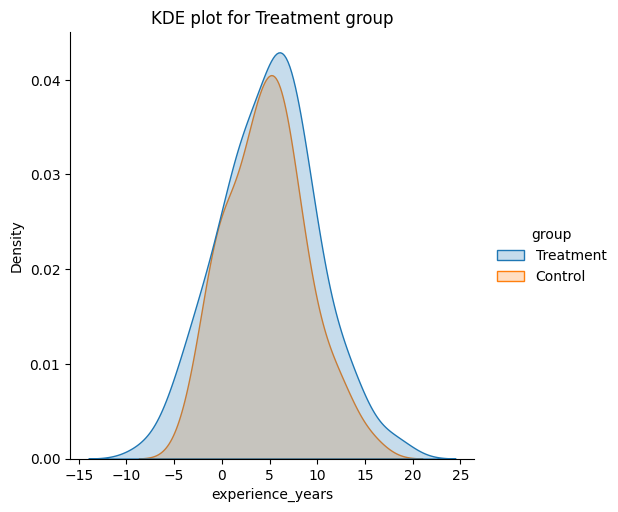

In [7]:
sns.displot(data=example_df, x='experience_years', hue='group', kind='kde', fill=True)
plt.title('KDE plot for Treatment group')
plt.show()

We implemented simple randomization above -- but the treatment group happens to have 0.3 years more experience.

If experience substantially affects productivity, **that imbalance can influence the measured treatment effect.**

>**Now implementing Blocking/ Stratified randomization to address the imbalace due to experience level:**

In [8]:
example_df1 = example_df.copy()
# create stratums/ groups based on experience level
example_df1["experience_level"] = pd.cut(example_df1["experience_years"],bins=[0, 3, 7, np.inf],labels=["Junior", "Mid", "Senior"])

# create & initialize a new column 'group' 
example_df1["group"] = None

# loops through each of the experience level
for level in example_df1["experience_level"].unique():
    # extract the indexes for particular level
    idx = example_df1.index[example_df1["experience_level"] == level]
    
    assignments = np.array(["Control", "Treatment"] * (len(idx) // 2 + 1))[:len(idx)]

    np.random.shuffle(assignments)

    example_df1.loc[idx, "group"] = assignments

example_df1.head()

# Checking the imbalance
example_df1.groupby("group")["experience_years"].agg(["count", "mean", "std"])

,count,mean,std
group,,,
Control,85,6.185199,3.635807
Treatment,83,6.060059,3.909278


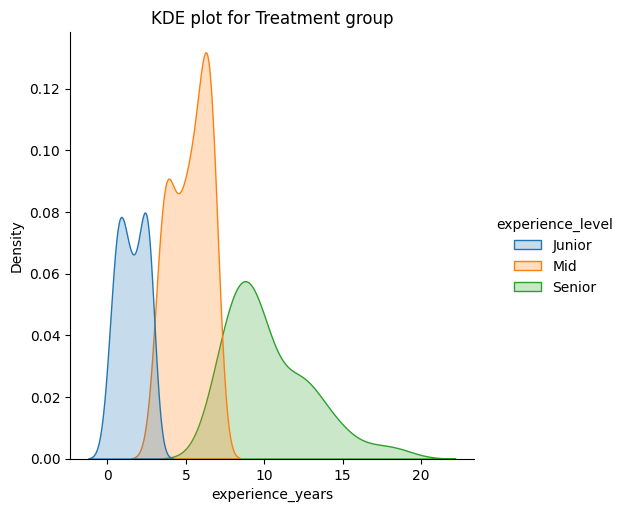

In [9]:
sns.displot(data=example_df1, x='experience_years', hue='experience_level', kind='kde', fill=True)
plt.title('KDE plot for Treatment group')
plt.show()

>By using Blocking randomization You should generally get much closer group means.

#### Confounding variable
The variable that might be causing the effect rather than the treatment applied.

____


In [11]:
pd.read_csv("./datasets/expd_datasets/hr_wellness.csv").head()

,Department,Wellness_Program_Status
0,Marketing,Enrolled
1,Sales,Enrolled
2,Marketing,Not Enrolled
3,Marketing,Not Enrolled
4,Sales,Enrolled


#### Cons of Block Randomization
- There's always a **credible possibility of chance imbalance** whenever a simple block randomization is implemented.<br>
The result could be, for example, that the Treatment group accidentally gets more senior engineers than the Control group. 

- Also , in small sample size, randomization does not balance important characteristics well

### Stratified randomization:
- Stratify (divide) into groups & then apply randomization **within each group**. 
- This method eliminates the chance imbalance that could occur within each group after sample has been divided.
- Also helps  eliminate/minimize the effects of any covariates on the treatment groups 

In [49]:
mrktg_df = pd.read_feather("./datasets/expd_datasets/marketing_data.feather")
print(mrktg_df.head())

print(f"Dataframe shape = {mrktg_df.shape}\n")

print(mrktg_df.info())

  Messaging_Style Time_of_Day  Click_Through_Rate  Conversions
0          Casual     Morning            0.640465          500
1          Formal     Evening            0.698533          598
2          Casual     Morning            0.257834          234
3          Casual     Evening            0.922971          602
4          Casual     Morning            0.476893          314
Dataframe shape = (950, 4)

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Messaging_Style     950 non-null    str    
 1   Time_of_Day         950 non-null    str    
 2   Click_Through_Rate  950 non-null    float64
 3   Conversions         950 non-null    int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 41.9 KB
None


In [59]:
# looking into messaging style & time of day categories
mrktg_df[["Time_of_Day","Messaging_Style"]].value_counts()

Time_of_Day  Messaging_Style
Morning      Formal             250
             Casual             239
Evening      Casual             231
             Formal             230
Name: count, dtype: int64

>Observation: Its clear that both -- time of day and messaging style can affect the conversion & click_throughs

- So, there is a possibilty of chance imbalance occuring if normal block randomization is implemented

In [83]:
# Example-1
# creating a copy df
mrktg_df2 = mrktg_df.copy()

# Applying just block randomization -- dividing into 2 blocks (treatment & control)
simple_block1 = mrktg_df2.sample(frac=0.5, replace=False, random_state=42)
simple_block2 = mrktg_df2.drop(simple_block1.index)

# adding a 'block' tag column for easy identification after concat
simple_block1['block_no'] = 1
simple_block2['block_no'] = 2

# concat the two dfs
simple_cmbnd = pd.concat([simple_block1, simple_block2], axis=0)

# count the combined values
simple_cmbnd["block_no"].value_counts()

# Assigning ttreatment groups
mrktg_df2["group_tag_simple"] = np.random.default_rng(seed=42).choice(["T", "C"], size=len(mrktg_df2))


print(mrktg_df2["Messaging_Style"].value_counts())
print(mrktg_df2[["Messaging_Style","group_tag_simple"]].value_counts())


Messaging_Style
Formal    480
Casual    470
Name: count, dtype: int64
Messaging_Style  group_tag_simple
Formal           C                   243
Casual           C                   240
Formal           T                   237
Casual           T                   230
Name: count, dtype: int64


In [98]:
# Example-2
# Applying treatment & control groups to the subjcts

# First, creating a series containing T/C  groups randomly assigned
# Testing only -- adding default 
np.random.default_rng(seed=42).choice(["T", "C"], size=10)

# Adding this series ditectly to the mktg2 dataframe
mrktg_df2["group_tag"] = np.random.choice(["T", "C"], size=len(mrktg_df2))

mrktg_df2.head()

print(mrktg_df2[["Messaging_Style","Time_of_Day"]].value_counts())
# checking the distribution of treatment groups for the overall dataframe
mrktg_df2[["Messaging_Style", "Time_of_Day","group_tag"]].value_counts().sort_index()

Messaging_Style  Time_of_Day
Formal           Morning        250
Casual           Morning        239
                 Evening        231
Formal           Evening        230
Name: count, dtype: int64


Messaging_Style  Time_of_Day  group_tag
Casual           Evening      C            116
                              T            115
                 Morning      C            126
                              T            113
Formal           Evening      C            104
                              T            126
                 Morning      C            118
                              T            132
Name: count, dtype: int64

In [110]:
pd.crosstab(mrktg_df2["Messaging_Style"], mrktg_df2["group_tag_simple"],mrktg_df2["Time_of_Day"], aggfunc="count")

group_tag_simple,C,T
Messaging_Style,,
Casual,240,230
Formal,243,237


> As seen above, there is a chance that there could be imbalance among the treatment groups 

But note that time of messaging would also impact the conversion rate. So this is the confounding variate that also needs to be factored in while assinging treatment groups 

In [82]:
mrktg_df2

,Messaging_Style,Time_of_Day,Click_Through_Rate,Conversions,group_tag_simple,group_tag
0,Casual,Morning,0.640465,500,T,T
1,Formal,Evening,0.698533,598,C,C
2,Casual,Morning,0.257834,234,C,C
3,Casual,Evening,0.922971,602,T,T
4,Casual,Morning,0.476893,314,T,T
...,...,...,...,...,...,...
945,Casual,Morning,0.759764,579,T,T
946,Casual,Evening,0.654387,65,C,C
947,Formal,Morning,0.269222,292,T,T
948,Formal,Evening,0.419846,25,C,C


____

In [93]:
475000*12

5700000

_____
